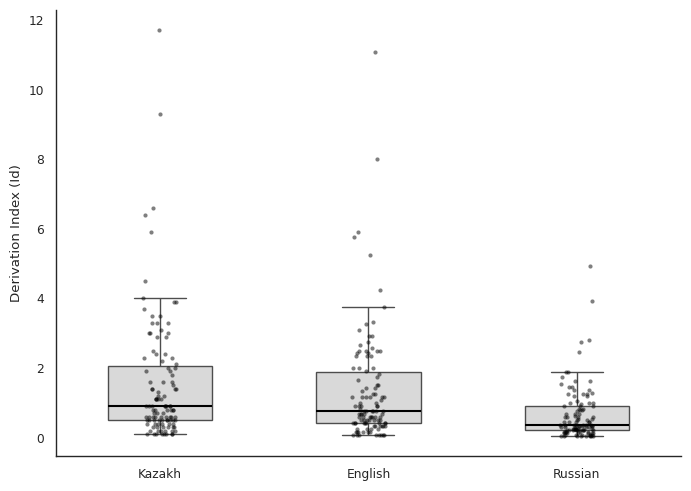

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- data (from ELEMENTА GRECO-LATINA: DICTIONARIUM. Azamatova, Suleimenova) ---
data = [
("A-, AN-", 11, 10, 11),
("AUTO-", 19, 18, 19),
("AD-", 66, 71, 67),
("ALLO-", 9, 9, 9),
("AMBI-, AMPHI-", 9, 11, 9),
("ANA-", 14, 14, 14),
("ANTI-", 23, 23, 24),
("ANTE-", 4, 5, 4),
("ANTHROPO-", 11, 11, 11),
("ARCHE-", 1, 1, 1),
("ARCHI-", 3, 4, 3),
("BI-", 16, 17, 16),
("-VERB-", 3, 5, 3),
("VOC-", 8, 8, 8),
("HETERO-", 16, 16, 16),
("HYPO-", 11, 11, 11),
("HYPER-", 19, 18, 19),
("GLOSS-, GLOTT-1", 14, 14, 14),
("-GLOSSIA-", 1, 1, 1),
("GLOTT-2", 5, 6, 5),
("GRAMMAT-1", 5, 5, 5),
("GRAMMAT-2", 1, 1, 1),
("-GRAMMA-", 1, 1, 1),
("-GRAPH-", 14, 14, 14),
("-GRAPHIA-", 2, 2, 2),
("DE-, DES-", 39, 40, 39),
("DI-", 16, 14, 16),
("DIA-", 30, 29, 30),
("DIS-", 22, 28, 22),
("-EMA", 15, 15, 15),
("-IVE", 93, 96, 94),
("IDEO-", 5, 5, 5),
("IDIO-", 13, 12, 13),
("ISO-", 5, 5, 5),
("-ICA", 33, 24, 42),
("IN-1", 21, 28, 22),
("IN-2", 33, 32, 33),
("INTER-", 23, 30, 23),
("INTRA-, INTRO-", 4, 4, 4),
("CACO-", 5, 5, 5),
("CATA-", 6, 6, 6),
("QUASI-", 6, 7, 7),
("KIN-", 7, 7, 7),
("CO-", 117, 133, 118),
("CONTRA-", 6, 7, 6),
("CRYPT-", 5, 5, 5),
("XENO-", 2, 2, 2),
("-LEX-", 20, 20, 20),
("-LECT", 6, 6, 6),
("-LINGU-", 29, 28, 29),
("-LOGIA", 33, 33, 33),
("-LOC-", 9, 9, 9),
("MACRO-", 8, 9, 9),
("MESO-", 2, 2, 2),
("META-", 35, 35, 35),
("MICRO-", 8, 8, 8),
("MONO-", 29, 29, 29),
("-MORPH-", 30, 30, 30),
("NEO-", 9, 9, 9),
("-OID", 4, 4, 4),
("HOMO-", 12, 14, 12),
("-ON", 2, 2, 2),
("-ONYM", 14, 14, 14),
("ONOMAS-, ONOMAT-", 6, 6, 6),
("ORTHO-[orto-], ORTHO-[orfo-]", 9, 9, 9),
("PASI-", 2, 2, 2),
("PALEO-", 3, 3, 3),
("PAN-", 6, 7, 7),
("PARA-", 37, 37, 37),
("PLER-", 2, 2, 2),
("POLY-", 30, 30, 30),
("POST-", 18, 17, 18),
("PRAGM-", 4, 4, 4),
("PRE-", 45, 45, 45),
("PRO-1", 25, 30, 25),
("PRO-2", 5, 7, 5),
("PROTO-", 9, 9, 9),
("PSEUDO-", 7, 7, 7),
("RE-", 64, 69, 66),
("RETRO-", 3, 3, 3),
("SEMI-", 24, 24, 24),
("-SIGN-", 5, 8, 5),
("-SYLLAB-", 6, 6, 6),
("SYN-", 39, 39, 39),
("SOCIO-", 9, 22, 22),
("SUB-", 40, 51, 45),
("SUPER-", 11, 11, 11),
("SUPRA-", 3, 3, 3),
("TAUTO-", 3, 3, 3),
("-TAGM-", 4, 4, 4),
("-TAX-", 1, 1, 1),
("-THESIS", 1, 1, 1),
("-TYPE-", 12, 12, 12),
("-TON-", 11, 11, 11),
("-TOPO-", 5, 5, 5),
("TRANS-", 31, 31, 31),
("TRI-", 8, 13, 8),
("UNI-", 9, 15, 13),
("-FIX", 1, 1, 1),
("-PHON-", 35, 35, 35),
("-PHRASEO-", 7, 7, 7),
("-PHTHONG-", 1, 1, 1),
("-CHRON-", 6, 6, 6),
("EU-", 5, 5, 5),
("EQUI-", 4, 4, 4),
("EXO-", 8, 8, 8),
("EX-", 59, 63, 59),
("EXTRA-", 8, 8, 8),
("ENDO-", 6, 6, 6),
("EPI-", 20, 21, 20),
("-ETHNO", 24, 24, 24),
]

df = pd.DataFrame(data, columns=["Morpheme", "KZ", "EN", "RU"])

# --- add Id ---
df["KZ_Id"] = df["KZ"] * 0.1
df["EN_Id"] = df["EN"] * (1000/12000)
df["RU_Id"] = df["RU"] * (1000/24000)

# --- long format ---
df_long_id = df.melt(
    id_vars="Morpheme",
    value_vars=["KZ_Id", "EN_Id", "RU_Id"],
    var_name="Language",
    value_name="Id"
)

# --- normalize ---
df_long_id["Language"] = df_long_id["Language"].map({
    "KZ_Id": "Kazakh",
    "EN_Id": "English",
    "RU_Id": "Russian"
})


sns.set(style="white", context="paper")

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_long_id,
    x="Language",
    y="Id",
    width=0.5,
    showfliers=False,
    color="#D9D9D9",
    boxprops=dict(edgecolor="#4D4D4D"),
    whiskerprops=dict(color="#4D4D4D"),
    capprops=dict(color="#4D4D4D"),
    medianprops=dict(color="#000000", linewidth=1.5)
)

sns.stripplot(
    data=df_long_id,
    x="Language",
    y="Id",
    color="#000000",
    alpha=0.5,
    jitter=0.08,
    size=3
)


plt.ylabel("Derivation Index (Id)")
plt.xlabel("")

sns.despine()
plt.tight_layout()
plt.show()






